# 01. EDA for the Rebuilt Notebook Story

**By the end of this notebook you should understand**
- the panel structure and scale
- why weights dominate evaluation
- why the old fixed cutoff was restrictive
- what stationarity and lag structure imply for modeling


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from codex_notebooks.support import (
    LEGACY_VAL_CUTOFF,
    apply_plot_style,
    build_codex_artifacts,
    export_figure,
    load_artifact,
    load_json_artifact,
    load_study_series,
)

apply_plot_style()
build_codex_artifacts(force=False, verbose=False)

overview = load_json_artifact('overview.json')
manifest = load_artifact('series_manifest.parquet')
chosen = load_artifact('chosen_manifest.parquet')
target_hist_full = load_artifact('target_hist_full.parquet')
target_hist_clip = load_artifact('target_hist_clip.parquet')
weight_hist_clip = load_artifact('weight_hist_clip.parquet')
weight_cumshare = load_artifact('weight_cumshare.parquet')
stationarity = load_artifact('stationarity_sample.parquet')
lag_summary = load_artifact('lag_summary.parquet')
study_series = load_study_series()
representative_series = study_series[study_series['role'] == 'representative'].copy()


## 1. Panel structure

The dataset is a large panel, not a single time series. That matters because identifiers, horizons, time order, and weights all matter simultaneously.


In [2]:
structure_df = pd.DataFrame(
    {
        'Measure': ['Total series', 'Codex-eligible series', 'Legacy-cutoff crossing', 'Legacy eligible (cross + length>=120)'],
        'Value': [
            f"{overview['legacy_cutoff_counts']['total_series']:,}",
            f"{overview['codex_counts']['eligible_codex']:,}",
            f"{overview['legacy_cutoff_counts']['crosses_legacy_cutoff']:,}",
            f"{overview['legacy_cutoff_counts']['legacy_eligible']:,}",
        ],
    }
)
display(structure_df)


,Measure,Value
0,Total series,"36,923"
1,Codex-eligible series,"25,622"
2,Legacy-cutoff crossing,"1,930"
3,Legacy eligible (cross + length>=120),"1,576"


## 2. Target distribution

Heavy tails mean a model can look visually decent in the center of the distribution while still doing badly on error-heavy spikes.

**Final deck figure:** `01_target_distribution.png`


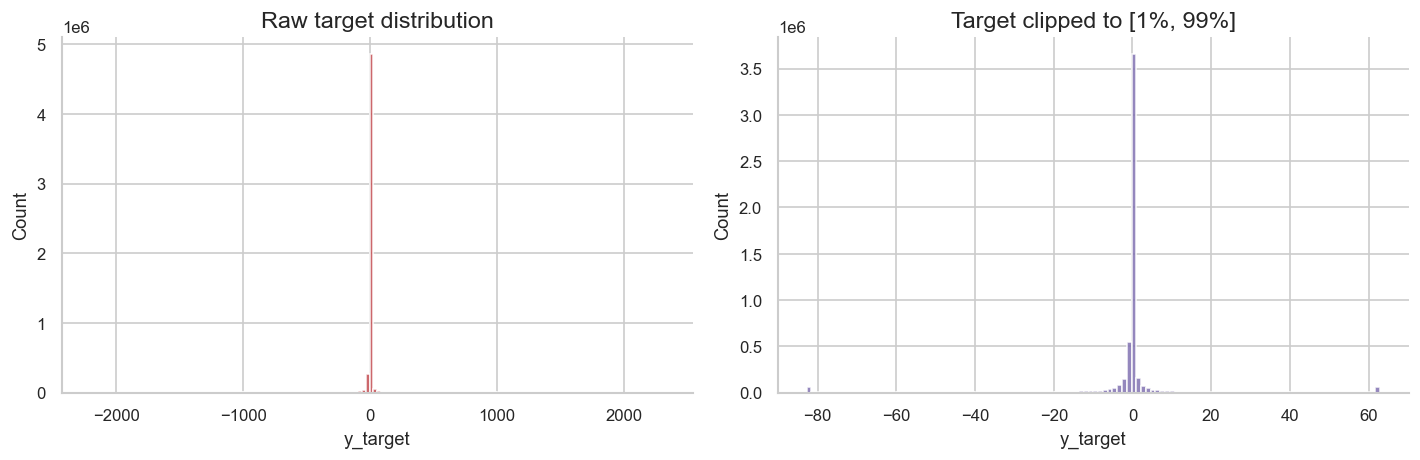

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    (target_hist_full['bin_left'] + target_hist_full['bin_right']) / 2,
    target_hist_full['count'],
    width=(target_hist_full['bin_right'] - target_hist_full['bin_left']),
    color='#C44E52',
    alpha=0.85,
)
axes[0].set_title('Raw target distribution')
axes[0].set_xlabel('y_target')
axes[0].set_ylabel('Count')

axes[1].bar(
    (target_hist_clip['bin_left'] + target_hist_clip['bin_right']) / 2,
    target_hist_clip['count'],
    width=(target_hist_clip['bin_right'] - target_hist_clip['bin_left']),
    color='#8172B2',
    alpha=0.85,
)
axes[1].set_title('Target clipped to [1%, 99%]')
axes[1].set_xlabel('y_target')
axes[1].set_ylabel('Count')

fig.tight_layout()
export_figure(fig, '01_target_distribution.png')
plt.show()


## 3. Weight concentration

The weighted skill score is only interpretable if we know how concentrated the weights are.

**Final deck figure:** `01_weight_concentration.png`


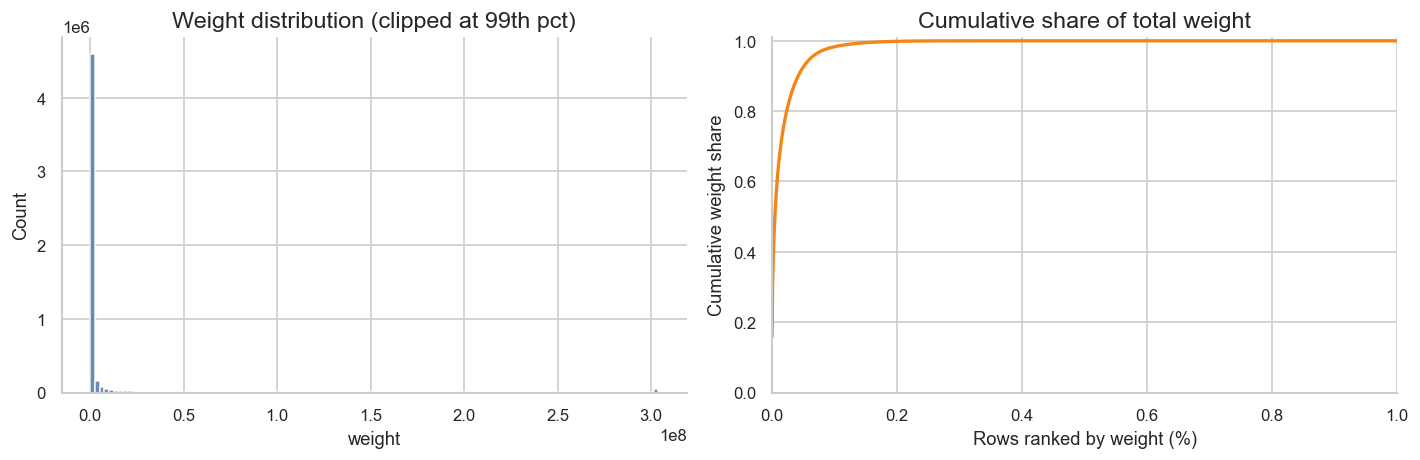

,Share,Weight share
0,Top 1%,0.641861
1,Top 5%,0.925807
2,Top 10%,0.983317


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    (weight_hist_clip['bin_left'] + weight_hist_clip['bin_right']) / 2,
    weight_hist_clip['count'],
    width=(weight_hist_clip['bin_right'] - weight_hist_clip['bin_left']),
    color='#4C78A8',
    alpha=0.85,
)
axes[0].set_title('Weight distribution (clipped at 99th pct)')
axes[0].set_xlabel('weight')
axes[0].set_ylabel('Count')

axes[1].plot(weight_cumshare['rank_pct'], weight_cumshare['cum_weight_share'], color='#F58518', linewidth=2)
axes[1].set_title('Cumulative share of total weight')
axes[1].set_xlabel('Rows ranked by weight (%)')
axes[1].set_ylabel('Cumulative weight share')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.01)

fig.tight_layout()
export_figure(fig, '01_weight_concentration.png')
plt.show()

pd.DataFrame(
    {
        'Share': ['Top 1%', 'Top 5%', 'Top 10%'],
        'Weight share': [
            overview['weight_summary']['top_1pct_share'],
            overview['weight_summary']['top_5pct_share'],
            overview['weight_summary']['top_10pct_share'],
        ],
    }
)


## 4. Why the old cutoff was restrictive

The rebuilt notebooks no longer use the legacy global cutoff for model comparison, but this EDA still explains why the old setup was restrictive.

**Final deck figure:** `01_cutoff_feasibility.png`


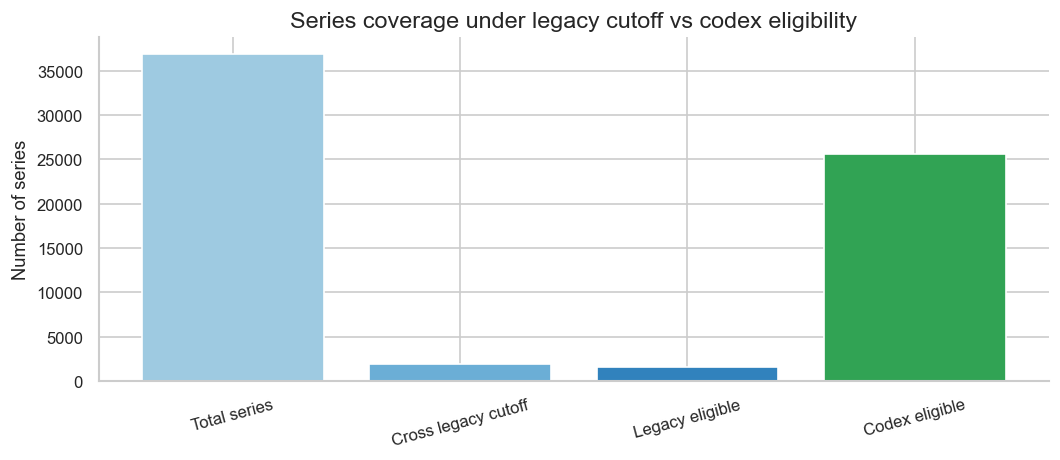

,Category,Count
0,Total series,36923
1,Cross legacy cutoff,1930
2,Legacy eligible,1576
3,Codex eligible,25622


In [5]:
counts = pd.DataFrame(
    {
        'Category': ['Total series', 'Cross legacy cutoff', 'Legacy eligible', 'Codex eligible'],
        'Count': [
            overview['legacy_cutoff_counts']['total_series'],
            overview['legacy_cutoff_counts']['crosses_legacy_cutoff'],
            overview['legacy_cutoff_counts']['legacy_eligible'],
            overview['codex_counts']['eligible_codex'],
        ],
    }
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(counts['Category'], counts['Count'], color=['#9ecae1', '#6baed6', '#3182bd', '#31a354'])
ax.set_title('Series coverage under legacy cutoff vs codex eligibility')
ax.set_ylabel('Number of series')
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
export_figure(fig, '01_cutoff_feasibility.png')
plt.show()
counts


## 5. Representative anchor series

The 4 anchor series are preserved because they teach different failure modes and strengths.

**Final deck figure:** `01_representative_series.png`


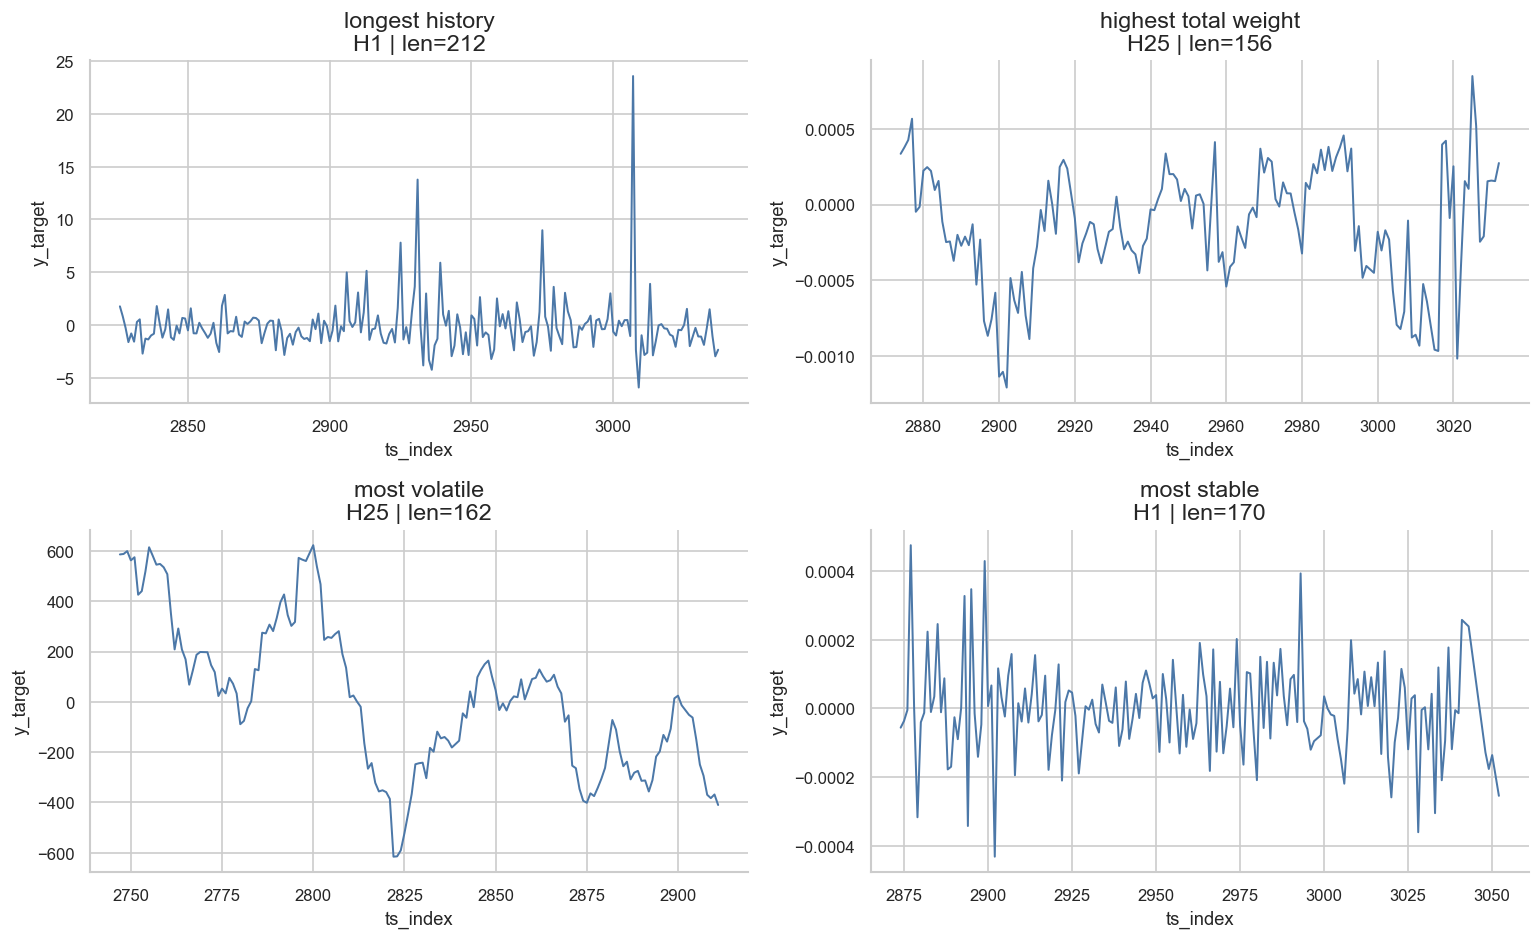

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
axes = axes.flatten()
order = ['longest history', 'highest total weight', 'most volatile', 'most stable']
chosen_ordered = chosen.set_index('reason').loc[order].reset_index()

for ax, (_, row) in zip(axes, chosen_ordered.iterrows()):
    s = representative_series[representative_series['series_id'] == row['series_id']].sort_values('ts_index')
    ax.plot(s['ts_index'], s['y_target'], color='#4C78A8', linewidth=1.2)
    ax.set_title(f"{row['reason']}\nH{int(row['horizon'])} | len={int(row['length'])}")
    ax.set_xlabel('ts_index')
    ax.set_ylabel('y_target')

fig.tight_layout()
export_figure(fig, '01_representative_series.png')
plt.show()


## 6. Stationarity and differencing

Raw levels are not universally safe. We compare stationarity verdicts before and after first differencing on a deterministic sample of eligible series.

**Final deck figure:** `01_stationarity.png`


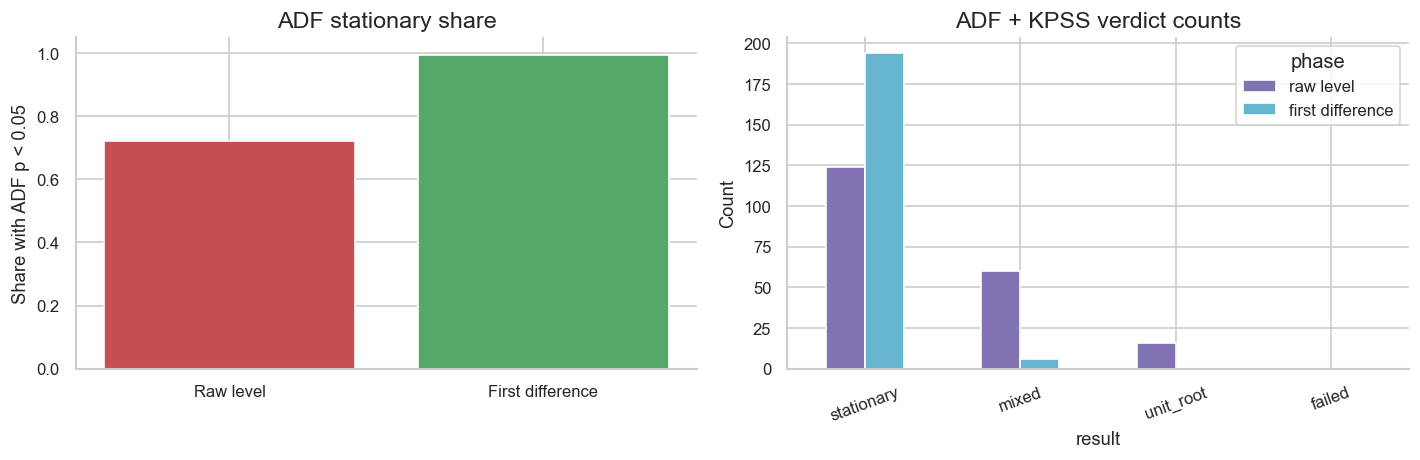

In [7]:
verdict_order = ['stationary', 'mixed', 'unit_root', 'failed']
verdict_counts = (
    stationarity[['verdict', 'verdict_d1']]
    .melt(var_name='phase', value_name='result')
    .assign(phase=lambda d: d['phase'].map({'verdict': 'raw level', 'verdict_d1': 'first difference'}))
    .groupby(['phase', 'result'])
    .size()
    .reset_index(name='count')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

raw_stationary = float((stationarity['adf_p'] < 0.05).mean())
diff_stationary = float((stationarity['adf_p_d1'] < 0.05).mean())
axes[0].bar(['Raw level', 'First difference'], [raw_stationary, diff_stationary], color=['#C44E52', '#55A868'])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Share with ADF p < 0.05')
axes[0].set_title('ADF stationary share')

pivot = verdict_counts.pivot(index='result', columns='phase', values='count').reindex(verdict_order).fillna(0)
pivot[['raw level', 'first difference']].plot.bar(ax=axes[1], color=['#8172B2', '#64B5CD'])
axes[1].set_title('ADF + KPSS verdict counts')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

fig.tight_layout()
export_figure(fig, '01_stationarity.png')
plt.show()


## 7. Panel-level lag structure

We aggregate lag structure over a deterministic sample rather than trusting a single anchor series.

**Final deck figure:** `01_panel_lags.png`


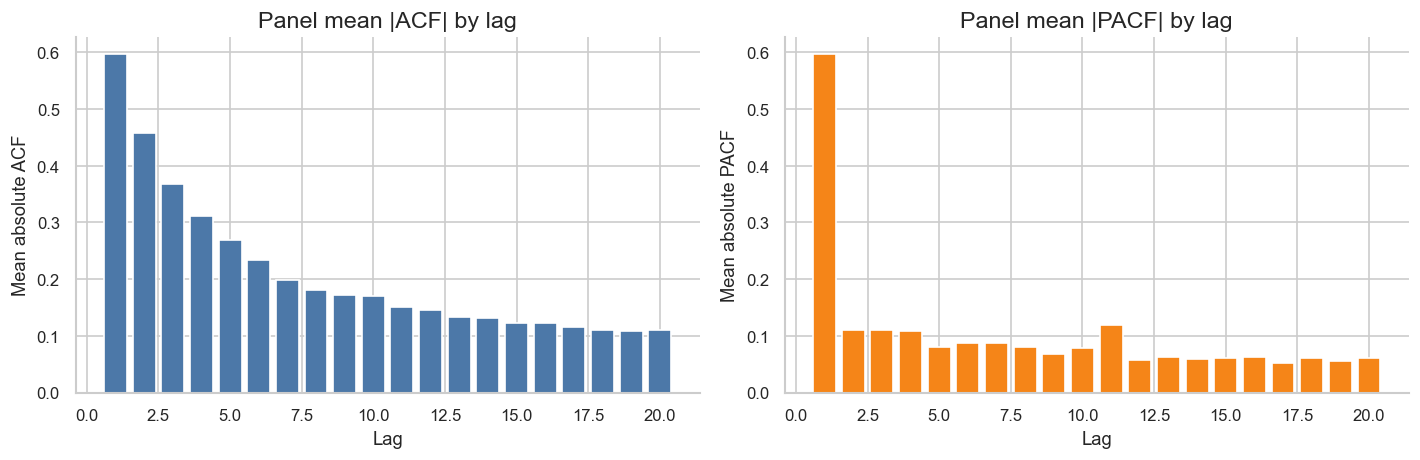

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(lag_summary['lag'], lag_summary['mean_abs_acf'], color='#4C78A8')
axes[0].set_title('Panel mean |ACF| by lag')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Mean absolute ACF')

axes[1].bar(lag_summary['lag'], lag_summary['mean_abs_pacf'], color='#F58518')
axes[1].set_title('Panel mean |PACF| by lag')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Mean absolute PACF')

fig.tight_layout()
export_figure(fig, '01_panel_lags.png')
plt.show()


## 8. What we learned

- the target is heavy-tailed and the weights are extremely concentrated
- the old `VAL_CUTOFF = 2880` logic produced a narrow usable pool
- first differencing materially improves stationarity evidence
- short lags matter more than complex seasonal structure in this rebuilt notebook view

## What this changes next

`02_classical.ipynb` will use the shared per-series chronological split and test simple baselines plus teachable classical models.
